In [4]:
from geopy.geocoders import Nominatim

def get_coordinates(city_name: str) -> tuple[float, float]:
    geolocator = Nominatim(user_agent="weather_app_langgraph")
    location = geolocator.geocode(city_name)

    # print(location)

    if location:
        return location.latitude, location.longitude
    raise ValueError(f"좌표를 찾을 수 없습니다: {city_name}")

In [5]:
get_coordinates("부산")

(35.1799528, 129.0752365)

In [6]:
from langchain_core.tools import tool
import httpx
import json

@tool
def get_weather(city_name: str) -> str:
    """도시 이름을 받아 해당 도시의 현재 날씨 정보를 반환합니다."""
    latitude, longitude = get_coordinates(city_name)
    url = f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&current_weather=true"
    response = httpx.get(url)
    response.raise_for_status() # 서버 응답한 결과가 성공했는지 확인
    return json.dumps(response.json())

tools = [get_weather]

In [7]:
tools[0].invoke({"city_name": "부산"})

'{"latitude": 35.2, "longitude": 129.0625, "generationtime_ms": 0.0718832015991211, "utc_offset_seconds": 0, "timezone": "GMT", "timezone_abbreviation": "GMT", "elevation": 26.0, "current_weather_units": {"time": "iso8601", "interval": "seconds", "temperature": "\\u00b0C", "windspeed": "km/h", "winddirection": "\\u00b0", "is_day": "", "weathercode": "wmo code"}, "current_weather": {"time": "2026-02-22T10:30", "interval": 900, "temperature": 9.6, "windspeed": 19.4, "winddirection": 292, "is_day": 0, "weathercode": 0}}'

In [8]:
# uv add python-dotenv langchain langchain_google_genai
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv()

model = init_chat_model(
    "google_genai:gemini-2.5-flash",
    temperature = 0
)

In [ ]:
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage

def call_model(state: MessagesState):
    # 날씨 도구 사용을 지시하는 시스템 메시지 생성
    system_message = SystemMessage(
        content="""당신은 유용한 AI 어시스턴트입니다.
사용자가 특정 지역의 날씨 정보를 물어볼 때에는 반드시 제공된 날씨 검색 도구를 사용하여 정확한 날씨를 확인한 후 답변하세요."""
    )
    
    # 기존 메시지 기록 맨 앞에 시스템 메시지 추가
    messages = [system_message] + state["messages"]
    
    # 도구를 모델에 바인딩한 후 호출 (수정된 부분)
    model_with_tools = model.bind_tools(tools)
    response = model_with_tools.invoke(messages)
    
    return {"messages": [response]}


In [10]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools)

graph_builder = StateGraph(MessagesState)

graph_builder.add_node("tool_node", tool_node)
graph_builder.add_node("call_model", call_model)

graph_builder.add_edge(START, "call_model")
graph_builder.add_conditional_edges(
    "call_model",
    lambda s: "tool_node" if s["messages"][-1].tool_calls else END,
    {"tool_node": "tool_node", END: END}
)
graph_builder.add_edge("tool_node", "call_model")

graph = graph_builder.compile()

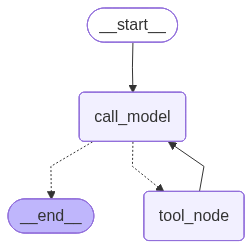

In [11]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
from langchain_core.messages import HumanMessage

graph.invoke({"messages": [HumanMessage(content="현재 부산의 날씨를 알려줘")]})

{'messages': [HumanMessage(content='현재 부산의 날씨를 알려줘', additional_kwargs={}, response_metadata={}, id='dad1f6d8-a15f-4dc4-b83b-c6b2ff891bc1'),
  AIMessage(content='네, 부산의 현재 날씨를 알려드릴게요.\n\n**부산의 현재 날씨는 맑고, 기온은 20.0°C입니다.**\n체감 온도는 19.8°C이며, 습도는 60%입니다.\n바람은 북서풍으로 1.5m/s로 불고 있습니다.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c84ef-e134-7160-a401-994d194e9911-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 56, 'output_tokens': 123, 'total_tokens': 179, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 45}})]}